In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path="/content/drive/MyDrive/Dataset/loan_approval_dataset.csv"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**EDA**

In [ ]:
df=pd.read_csv(file_path)
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [ ]:
df.shape

(4269, 13)

In [ ]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
df.describe(include="object")

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


In [ ]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [ ]:
# column names have leading spaces
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [ ]:
# dropping laon id column as it is meaning less
df.drop(columns=["loan_id"], inplace=True)

In [ ]:
df.dtypes

,0
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64
luxury_assets_value,int64


In [ ]:
df.isnull().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


In [ ]:
df.duplicated().sum()

np.int64(0)

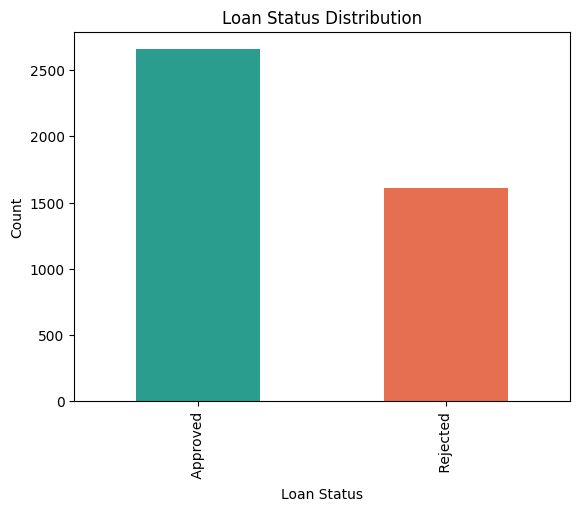

In [ ]:
plt.figure()
df["loan_status"].value_counts().plot(kind="bar", color=["#2a9d8f", "#e76f51"])
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

9


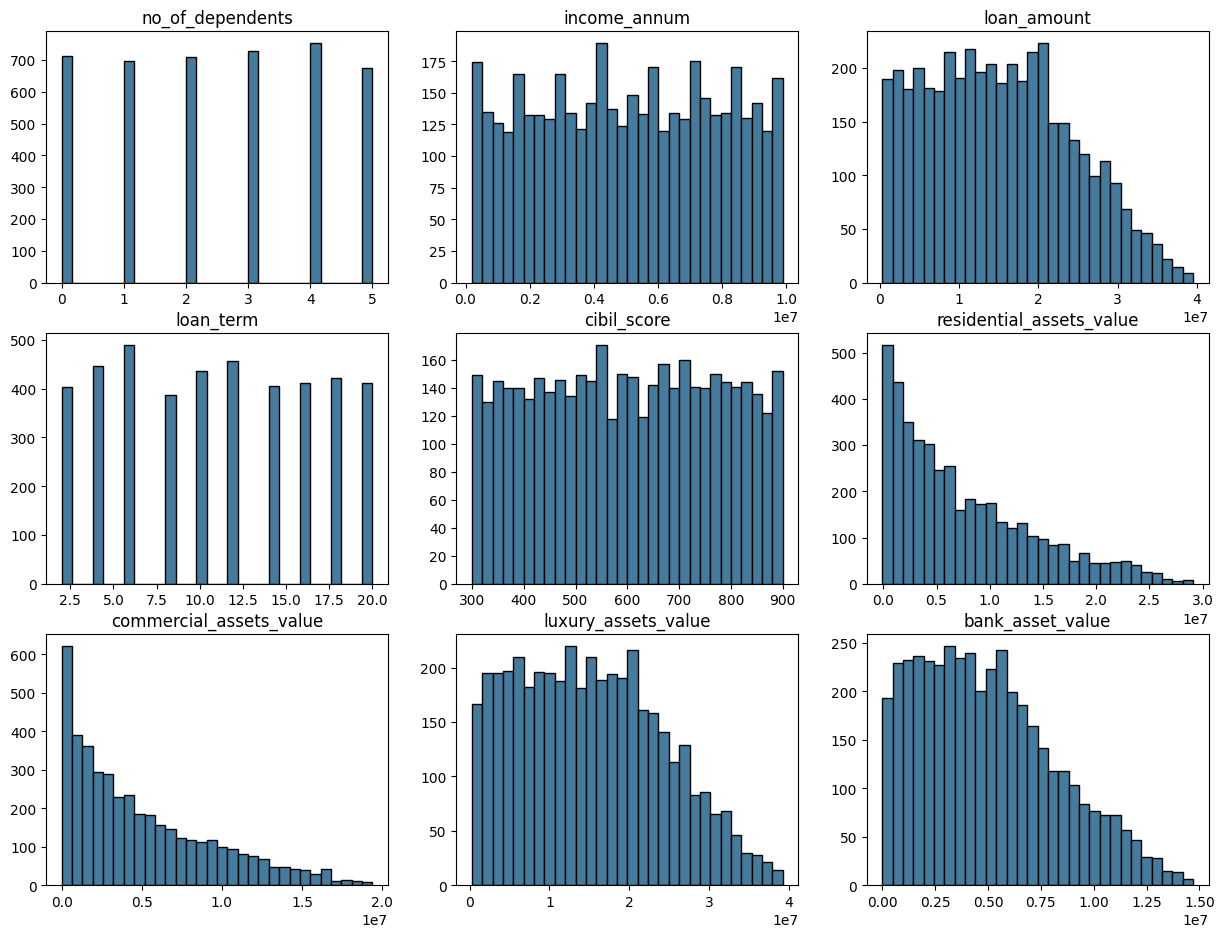

In [ ]:
# Numerical feature distributions using histograms

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(len(numeric_cols))

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
axes = axes.flatten() # coz ut give 2d array of axes
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color="#457b9d", edgecolor="black")
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
   fig.delaxes(axes[j])

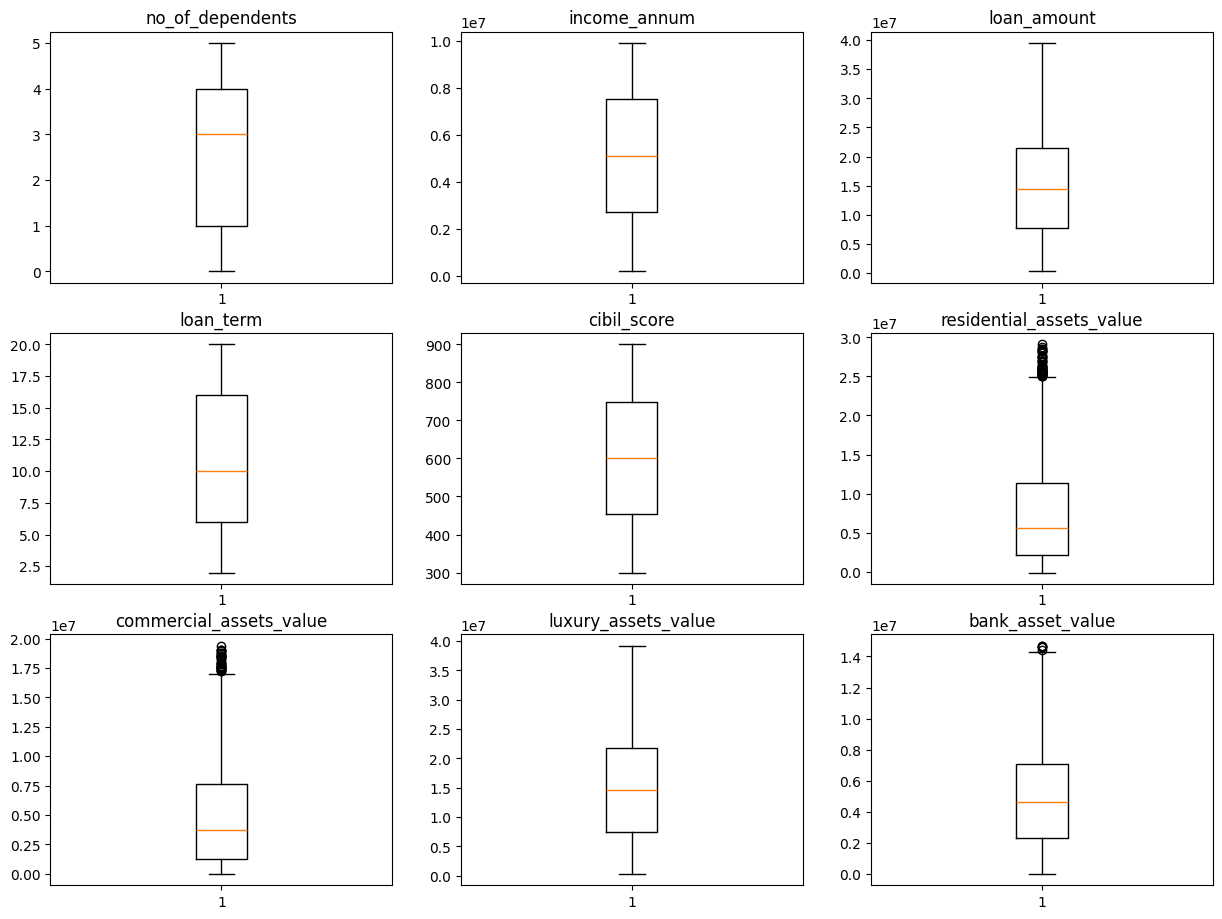

In [ ]:
# Box plot to check outliers

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)

for j in range(len(numeric_cols),len(axes)):
   fig.delaxes(axes[j])

Text(0.5, 1.0, 'Correlation Heatmap (Numerical Features)')

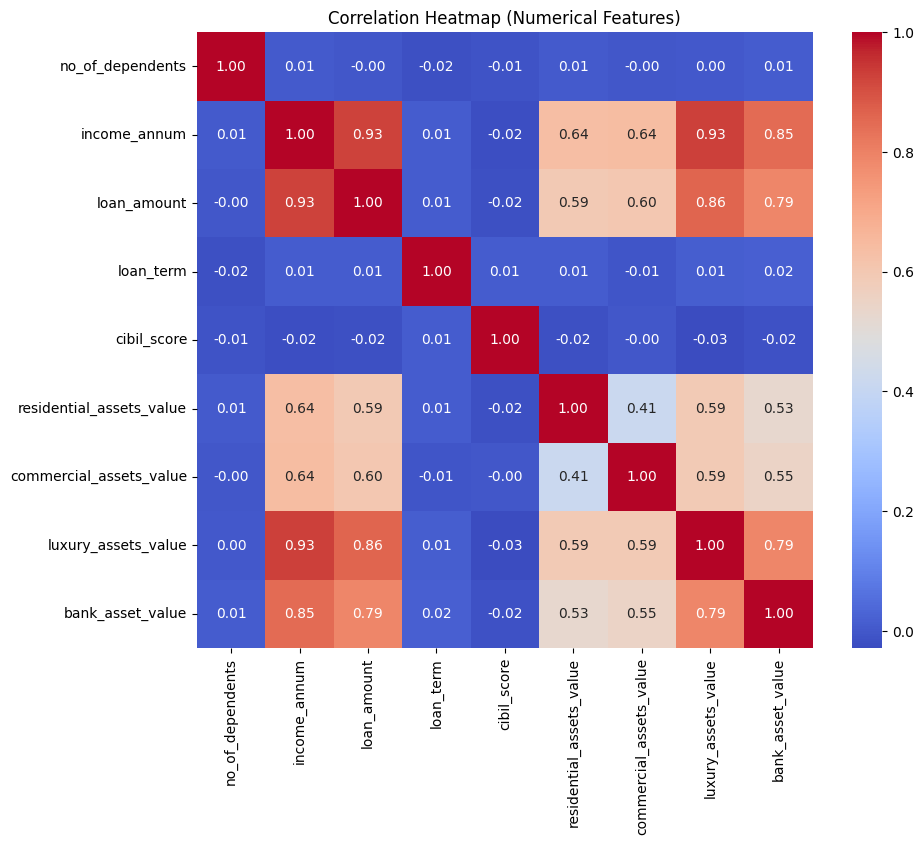

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()               # pairwise Pearson correlation
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numerical Features)")

In [ ]:
# as loan status has spaces
df["loan_status"]=df["loan_status"].str.strip()
df["education"]=df["education"].str.strip()
df["self_employed"]=df["self_employed"].str.strip()

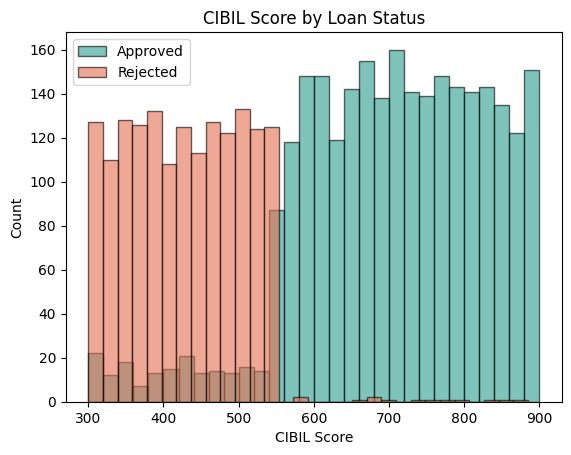

In [ ]:
plt.figure()
approved = df[df["loan_status"] == "Approved"]["cibil_score"]
rejected = df[df["loan_status"] == "Rejected"]["cibil_score"]
plt.hist(approved, bins=30, alpha=0.6, label="Approved", color="#2a9d8f", edgecolor="black")
plt.hist(rejected, bins=30, alpha=0.6, label="Rejected", color="#e76f51", edgecolor="black")
plt.title("CIBIL Score by Loan Status")
plt.xlabel("CIBIL Score")
plt.ylabel("Count")
plt.legend()

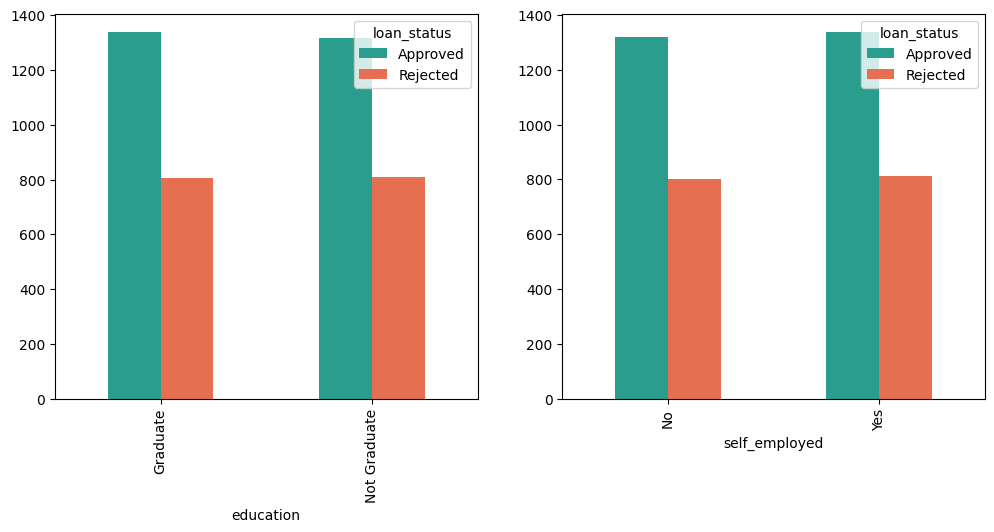

In [ ]:
#Categorical features vs target

Categorical_features=[df["education"],df["self_employed"]]
fog, axes=plt.subplots(1,2,figsize=(12,5))

for i,cols in enumerate(Categorical_features):
  ct=pd.crosstab(cols,df["loan_status"])
  ct.plot(kind="bar",ax=axes[i],color=["#2a9d8f","#e76f51"])

**Feature Engineering**

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

In [ ]:
# all assests feature

df["total_assets_value"] = (
    df["residential_assets_value"]
    + df["commercial_assets_value"]
    + df["luxury_assets_value"]
    + df["bank_asset_value"]
)

In [ ]:
# loan to  anual income ratio featuee
df["loan_to_income_ratio"] = df["loan_amount"] / df["income_annum"]

In [ ]:
# assest to loan ratio
# + 1 is used to avoid divison by zero
df["asset_to_loan_ratio"] = df["total_assets_value"] / (df["loan_amount"] + 1)

In [ ]:
#monthly loan amount
df["approx_monthly_installment"] = df["loan_amount"] / (df["loan_term"] * 12)

In [ ]:
# cibil bucket feature
def cibil_bucket(score):
    if score < 550:
        return 0   # poor
    elif score < 650:
        return 1   # fair
    elif score < 750:
        return 2   # good
    else:
        return 3   # excellent

df["cibil_score_bucket"] = df["cibil_score"].apply(cibil_bucket)


**Train | Test Split**

In [ ]:
# separate input and target

X = df.drop(columns=["loan_status"])

# model_b_features = [
#     "cibil_score",
#     # "cibil_score_bucket",
#     "loan_term",
#     "loan_to_income_ratio",
#     "asset_to_loan_ratio"
# ]

# X = X[model_b_features]
y = (df["loan_status"] == "Approved").astype(int)

categorical_features = ["education", "self_employed"]
numeric_features = [c for c in X.columns if c not in categorical_features]

In [ ]:
X.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'total_assets_value', 'loan_to_income_ratio', 'asset_to_loan_ratio',
       'approx_monthly_installment', 'cibil_score_bucket'],
      dtype='object')

In [ ]:
#stratify=y keeps the same Approved/Rejected ratio in both splits

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (3415, 16)  Test shape: (854, 16)


In [ ]:
# encoding and scaling
preprocessor = ColumnTransformer(transformers=[
    ("cat", OrdinalEncoder(), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

**Model Selection, training and predict**

In [ ]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

results = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]    # probability of Approved
    #print(pipe.classes_)

    # train_pred = pipe.predict(X_train)
    # print(accuracy_score(y_train, train_pred))
    # print(accuracy_score(y_test, preds))
    # print("\n")

    scores = cross_val_score(
            pipe,
            X,
            y,
            cv=5,
            scoring="f1"
            )

    print(scores)
    print(scores.mean())



    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    }
    fitted_pipelines[name] = pipe

[0.98016997 0.97528517 0.97904762 0.9742612  0.96928983]
0.9756107580441787
[0.99906103 0.9971831  0.99905927 1.         1.        ]
0.9990606795366113
[1.         0.99905927 1.         1.         1.        ]
0.9998118532455316


In [ ]:
for name, metrics in results.items():
    print(name)
    print(f"Accuracy: {metrics['accuracy']:.2f}")
    print(f"Precison: {metrics['precision']:.2f}")
    print(f"Recall: {metrics['recall']:.2f}")
    print(f"F1: {metrics['f1']:.2f}")
    print(f"ROC_AUC: {metrics['roc_auc']:.2f}")
    print("\n")

LogisticRegression
Accuracy: 0.98
Precison: 0.99
Recall: 0.97
F1: 0.98
ROC_AUC: 0.99


RandomForest
Accuracy: 1.00
Precison: 1.00
Recall: 1.00
F1: 1.00
ROC_AUC: 1.00


GradientBoosting
Accuracy: 1.00
Precison: 1.00
Recall: 1.00
F1: 1.00
ROC_AUC: 1.00




In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, preds))
print("\n")
print(f"x columns \n {X.columns}")

[[323   0]
 [  0 531]]


x columns 
 Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'total_assets_value', 'loan_to_income_ratio', 'asset_to_loan_ratio',
       'approx_monthly_installment', 'cibil_score_bucket'],
      dtype='object')


In [ ]:
print(y_test.value_counts())

loan_status
1    531
0    323
Name: count, dtype: int64


In [ ]:
# features importance

gb = fitted_pipelines["GradientBoosting"]

model = gb.named_steps["classifier"]

importance = model.feature_importances_

for feature, score in zip(
    X.columns,
    importance
):
    print(f"{feature} : {score}")


no_of_dependents : 0.0
education : 0.0
self_employed : 0.0
income_annum : 2.9608855664823833e-08
loan_amount : 1.018377704493938e-06
loan_term : 0.0844293730936181
cibil_score : 0.635577322411937
residential_assets_value : -1.5671552801664418e-17
commercial_assets_value : 5.708608784164046e-16
luxury_assets_value : 1.5835161838833028e-06
bank_asset_value : 5.310875747928317e-07
total_assets_value : 6.340118992634054e-09
loan_to_income_ratio : 0.09059772600573623
asset_to_loan_ratio : 0.014343212887482023
approx_monthly_installment : 2.768012053829135e-06
cibil_score_bucket : 0.1750464286587344


In [ ]:
best_model_name = max(results, key=lambda k: results[k]["f1"])
print(f"Best model: {best_model_name}")

best_pipeline = fitted_pipelines[best_model_name]

Best model: GradientBoosting


**Saving the pipeline**

In [ ]:
import joblib

joblib.dump(best_pipeline, "loan_approval_pipeline.pkl")

['loan_approval_pipeline.pkl']